# SafeWatch Dataset EDA

Khám phá dữ liệu QMI và WEDA-FALL sau khi tải và merge. Hai schema raw được giữ riêng trong `data/raw/merge/QMI` và `data/raw/merge/WEDA`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name in {'data', 'notebooks'} else Path.cwd()
QMI_DIR = ROOT / 'data' / 'raw' / 'QMI'
WEDA_DIR = ROOT / 'data' / 'raw' / 'WEDA-FALL'
WEDA_EDA_DIR = WEDA_DIR / 'dataset' / '5Hz'
MERGE_DIR = ROOT / 'data' / 'raw' / 'merge'
print('Project:', ROOT)
print('QMI:', QMI_DIR.exists(), 'WEDA:', WEDA_DIR.exists(), 'Merge:', MERGE_DIR.exists())

Project: /home/vinh_shindo/safewatch-fall-detector-edge-ai
QMI: True WEDA: True Merge: True


## 1. File inventory

In [2]:
def csv_files(folder):
    return sorted(folder.rglob('*.csv'))

qmi_files = csv_files(QMI_DIR)
weda_files = sorted(WEDA_EDA_DIR.rglob('*_accel.csv')) if WEDA_EDA_DIR.exists() else csv_files(WEDA_DIR)
inventory = pd.DataFrame({
    'dataset': ['QMI', 'WEDA-FALL 5Hz accel'],
    'csv_files': [len(qmi_files), len(weda_files)],
    'root': [str(QMI_DIR), str(WEDA_EDA_DIR if WEDA_EDA_DIR.exists() else WEDA_DIR)],
})
inventory

,dataset,csv_files,root
0,QMI,9,/home/vinh_shindo/safewatch-fall-detector-edge...
1,WEDA-FALL 5Hz accel,969,/home/vinh_shindo/safewatch-fall-detector-edge...


## 2. QMI schema, sessions, and labels

In [3]:
qmi_frames = []
for path in qmi_files:
    frame = pd.read_csv(path)
    frame['source_file'] = path.name
    qmi_frames.append(frame)
qmi = pd.concat(qmi_frames, ignore_index=True)
print('Shape:', qmi.shape)
print('Columns:', list(qmi.columns))
print('Sessions:', qmi['session_id'].nunique())
qmi.groupby(['source_file', 'label']).agg(rows=('session_id', 'size'), sessions=('session_id', 'nunique'))

Shape: (5425, 12)
Columns: ['session_id', 'label', 'timestamp_ms', 'accel_x(m_s2)', 'accel_y(m_s2)', 'accel_z(m_s2)', 'gyro_x(deg_s)', 'gyro_y(deg_s)', 'gyro_z(deg_s)', 'pitch_deg', 'roll_deg', 'source_file']
Sessions: 175


,,rows,sessions
source_file,label,,
doing.csv,Other,1054,34
fall_back.csv,Fall_Back,434,14
fall_front.csv,Fall_Front,465,15
fall_left.csv,Fall_Left,341,11
fall_right.csv,Fall_Right,434,14
jumping.csv,Standing,217,7
sitting.csv,Sitting,1054,34
standing.csv,Standing,403,13
walking.csv,Walking,1023,33


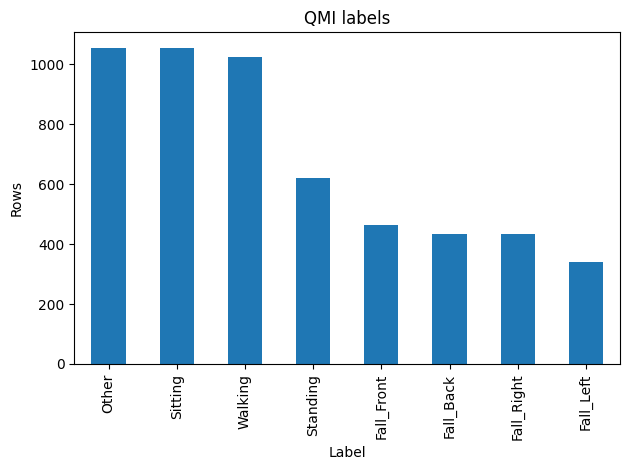

In [4]:
qmi['label'].value_counts().plot(kind='bar', title='QMI labels')
plt.xlabel('Label')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

## 3. WEDA-FALL file and activity distribution

In [5]:
weda_rows = []
for path in weda_files:
    frame = pd.read_csv(path)
    weda_rows.append({
        'file': str(path.relative_to(WEDA_EDA_DIR if WEDA_EDA_DIR.exists() else WEDA_DIR)),
        'rows': len(frame),
        'activity_folder': path.parent.name,
        'columns': ', '.join(map(str, frame.columns)),
    })
weda_summary = pd.DataFrame(weda_rows)
print('Files:', len(weda_summary))
print('Rows:', int(weda_summary['rows'].sum()) if not weda_summary.empty else 0)
display(weda_summary.head(30))

Files: 969
Rows: 60464


,file,rows,activity_folder,columns
0,D01/U01_R01_accel.csv,95,D01,"accel_time_list, accel_x_list, accel_y_list, a..."
1,D01/U01_R02_accel.csv,94,D01,"accel_time_list, accel_x_list, accel_y_list, a..."
2,D01/U01_R03_accel.csv,91,D01,"accel_time_list, accel_x_list, accel_y_list, a..."
3,D01/U02_R01_accel.csv,135,D01,"accel_time_list, accel_x_list, accel_y_list, a..."
4,D01/U02_R02_accel.csv,140,D01,"accel_time_list, accel_x_list, accel_y_list, a..."
5,D01/U02_R03_accel.csv,130,D01,"accel_time_list, accel_x_list, accel_y_list, a..."
6,D01/U03_R01_accel.csv,78,D01,"accel_time_list, accel_x_list, accel_y_list, a..."
7,D01/U03_R02_accel.csv,65,D01,"accel_time_list, accel_x_list, accel_y_list, a..."
8,D01/U03_R03_accel.csv,66,D01,"accel_time_list, accel_x_list, accel_y_list, a..."
9,D01/U04_R01_accel.csv,98,D01,"accel_time_list, accel_x_list, accel_y_list, a..."


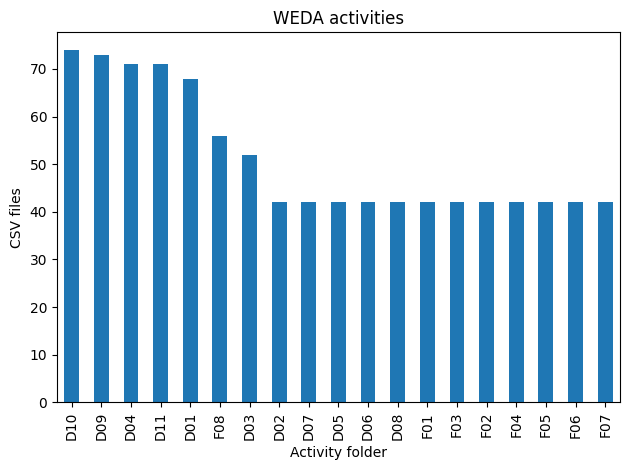

In [6]:
if not weda_summary.empty:
    weda_summary['activity_folder'].value_counts().head(30).plot(kind='bar', title='WEDA activities')
    plt.xlabel('Activity folder')
    plt.ylabel('CSV files')
    plt.tight_layout()
    plt.show()

## 4. Merge validation and conclusion

In [7]:
manifest_path = MERGE_DIR / 'manifest.csv'
manifest = pd.read_csv(manifest_path) if manifest_path.exists() else pd.DataFrame()
print('Merged files:', len(manifest))
if not manifest.empty:
    display(manifest.groupby('source').size().rename('files').to_frame())
print('Conclusion: use WEDA-FALL for pretraining and QMI for fine-tuning; keep raw schemas separate and split by session/user.')

Merged files: 15357


,files
source,
QMI,9
WEDA,15348


Conclusion: use WEDA-FALL for pretraining and QMI for fine-tuning; keep raw schemas separate and split by session/user.
